# Overview - Welcome to week 4 practical (coding part)

In this practical, you will learn how to ***summarise and explore*** data using Python and pandas. You will practise calculating common summary statistics such as the mean, median, minimum, and maximum, as well as identifying missing values in a dataset.

You will also learn how to ***group data*** using groupby() and compute ***summary statistics*** for different groups. Finally, you will create ***simple visualisations*** to help understand the data, including bar charts for grouped results and scatter plots to explore relationships between variables.

The exercises in this practical use the ***Breast Cancer Wiscons***in dataset, a classic dataset often used for learning data analysis techniques.

## 🐍 Python Libraries We'll Use

- **[pandas](https://pypi.org/project/pandas/)** - a Python package that provides fast, flexible, and expressive data structures designed to make working with "relational" or "labeled" data both easy and intuitive.

- **[Matplotlib](https://matplotlib.org/stable/index.html)** - Matplotlib is a low level graph plotting library in python that serves as a visualization utility.

In [1]:
# Please import before using.
import pandas as pd
import matplotlib.pyplot as plt

## 📊 Dataset We'll Use

In this practical, we will use the ***[Breast Cancer Wisconsin (Original)](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)*** dataset, a well-known dataset from the UCI Machine Learning Repository. The dataset contains measurements of breast cell samples collected from medical examinations.

*Each row represents a cell sample, and the variables describe different characteristics of the cell nuclei, such as clump thickness, cell size uniformity, and mitoses.* These features help doctors evaluate whether a tumour is likely to be benign or malignant.

The dataset includes a class variable that indicates the diagnosis:

***2 – Benign (non-cancerous)***

***4 – Malignant (cancerous)***

Some values in the dataset are recorded as **"?"**, which represent missing data. In this practical, we will also learn how to detect and handle these missing values while summarising the dataset.

In [2]:
# Download the dataset from iLearn and load it.
columns = [
"id",
"clump_thickness",
"cell_size_uniformity",
"cell_shape_uniformity",
"marginal_adhesion",
"single_epithelial_size",
"bare_nuclei",
"bland_chromatin",
"normal_nucleoli",
"mitoses",
"class"
]

df = pd.read_csv("breast-cancer-wisconsin.data", names=columns)

In [3]:
# Let's quickly take a look at the data first.
# Displaying first few rows of the dataframe
print(df.head())

        id  clump_thickness  cell_size_uniformity  cell_shape_uniformity  \
0  1000025                5                     1                      1   
1  1002945                5                     4                      4   
2  1015425                3                     1                      1   
3  1016277                6                     8                      8   
4  1017023                4                     1                      1   

   marginal_adhesion  single_epithelial_size bare_nuclei  bland_chromatin  \
0                  1                       2           1                3   
1                  5                       7          10                3   
2                  1                       2           2                3   
3                  1                       3           4                3   
4                  3                       2           1                3   

   normal_nucleoli  mitoses  class  
0                1        1      2  
1     

# Aggregation: mean, median, min, max

Data scientists often begin their analysis by ***summarising key characteristics*** of a dataset. Summary statistics help us quickly understand the typical values, variability, and range of the data.

In this section, we will compute basic statistics such as the mean, median, minimum, and maximum for selected variables in the dataset.


In [4]:
# Compute the mean of a single column, e.x. clump_thickness.
mean_clump = df["clump_thickness"].mean()

# Compute the median of a single column, e.x. cell_size_uniformity.
median_cell = df["cell_size_uniformity"].median()

# Find the minimum and maximum values of mitoses.
min_mitoses = df["mitoses"].min()
max_mitoses = df["mitoses"].max()

print(mean_clump)
print(median_cell)
print(min_mitoses, max_mitoses)

4.417739628040057
1.0
1 10


In [5]:
# If you want to generate a detailed dataset description
# Try this command
df.describe()

,id,clump_thickness,cell_size_uniformity,cell_shape_uniformity,marginal_adhesion,single_epithelial_size,bland_chromatin,normal_nucleoli,mitoses,class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


# Counting Missing Values

Real-world datasets often contain ***missing values***. Missing data usually appears as empty cells or special values such as **NaN**. Before analysing a dataset, it is important to identify and handle missing values because they may affect calculations and statistical summaries.

In this dataset, missing values are not recorded as empty cells. Instead, they are represented by the character "?". Because pandas does not automatically recognise **"?"** as missing data, we need to ***convert these values into NaN before performing analysis***.

After converting them, we can use pandas functions to detect and count missing values in the dataset.

In [6]:
# convert ? values into NaN
df = df.replace("?", pd.NA)

# Count #. missings in a single column
missing_count = df["bare_nuclei"].isna().sum()

print(missing_count)

16


In [7]:
# check out the whole dataset
df.isna().sum()


id                         0
clump_thickness            0
cell_size_uniformity       0
cell_shape_uniformity      0
marginal_adhesion          0
single_epithelial_size     0
bare_nuclei               16
bland_chromatin            0
normal_nucleoli            0
mitoses                    0
class                      0
dtype: int64

In [8]:
# Or try this command
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      699 non-null    int64 
 1   clump_thickness         699 non-null    int64 
 2   cell_size_uniformity    699 non-null    int64 
 3   cell_shape_uniformity   699 non-null    int64 
 4   marginal_adhesion       699 non-null    int64 
 5   single_epithelial_size  699 non-null    int64 
 6   bare_nuclei             683 non-null    object
 7   bland_chromatin         699 non-null    int64 
 8   normal_nucleoli         699 non-null    int64 
 9   mitoses                 699 non-null    int64 
 10  class                   699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


# Grouping Data

In many analyses, we are interested in ***comparing different groups within a dataset***. For example, we may want to *compare measurements between different categories or classes*.

Using the **groupby()** function in pandas allows us to split the data into groups and compute summary statistics for each group separately.

This helps us understand how different groups vary in their characteristics.

In [9]:
# Check out the clump_thickness mean of two classes
group_mean = df.groupby("class")["clump_thickness"].mean()

print(group_mean)

class
2    2.956332
4    7.195021
Name: clump_thickness, dtype: float64


## Summarising Multiple Variables

Group by class and compute the mean of the following variables:

* clump_thickness
* cell_size_uniformity
* mitoses

In [10]:
summary = df.groupby("class")[[
"clump_thickness",
"cell_size_uniformity",
"mitoses"
]].mean()

print(summary)

       clump_thickness  cell_size_uniformity   mitoses
class                                                 
2             2.956332              1.325328  1.063319
4             7.195021              6.572614  2.589212


## 🧑‍🎓 Your Turn

Group by class and compute the median of the following variables:

* cell_size_uniformity
* marginal_adhesion
* mitoses

In [11]:
# Your code here ...
summary = df.groupby("class")[[
"cell_size_uniformity",
"marginal_adhesion",
"mitoses"
]].median()

print(summary)

       cell_size_uniformity  marginal_adhesion  mitoses
class                                                  
2                       1.0                1.0      1.0
4                       6.0                5.0      1.0


# Visualising Summaries – Bar Charts

After computing summary statistics, it is often helpful to visualise the results. Visualisations make it easier to identify patterns and differences between groups.

Bar charts are commonly used to display aggregated values for different categories, such as the average value of a variable for each class.

**Task** - Create a bar chart showing the average clump thickness for each tumour class.


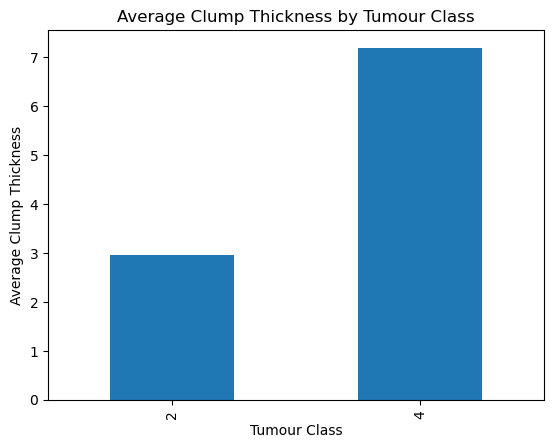

In [12]:
# calculate the mean first
group_mean = df.groupby("class")["clump_thickness"].mean()

# visualization
group_mean.plot(kind="bar")

plt.xlabel("Tumour Class")
plt.ylabel("Average Clump Thickness")
plt.title("Average Clump Thickness by Tumour Class")

plt.show()

# Exploring Relationships – Scatter Plots

Scatter plots are useful for exploring relationships between two numerical variables. Each point represents an observation in the dataset.

By examining the pattern of points, we can see whether two variables tend to increase together, decrease together, or show no clear relationship.

**Task** - Create a scatter plot showing the relationship between:

* clump_thickness

* cell_size_uniformity

Add axis labels and a title.

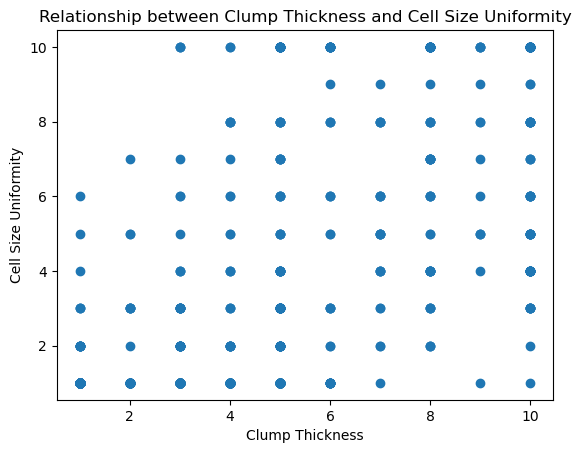

In [13]:
plt.scatter(
df["clump_thickness"],
df["cell_size_uniformity"]
)

plt.xlabel("Clump Thickness")
plt.ylabel("Cell Size Uniformity")
plt.title("Relationship between Clump Thickness and Cell Size Uniformity")

plt.show()

**Task** - Create a scatter plot showing the relationship between:

* cell_shape_uniformity

* bland_chromatin

Add appropriate axis labels and a title.

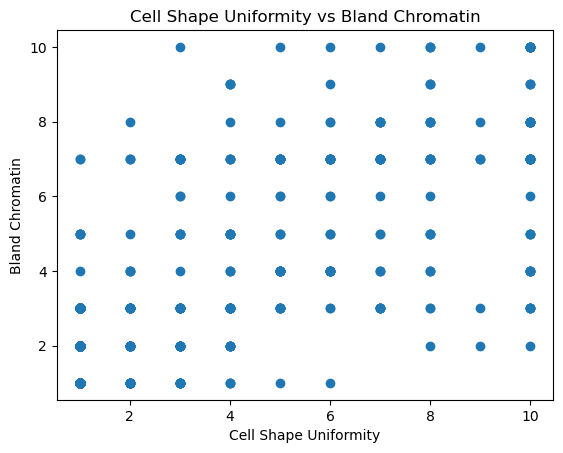

In [14]:
plt.scatter(
    df["cell_shape_uniformity"],
    df["bland_chromatin"]
)

plt.xlabel("Cell Shape Uniformity")
plt.ylabel("Bland Chromatin")
plt.title("Cell Shape Uniformity vs Bland Chromatin")

plt.show()

**Question**

Why do the points in the scatter plot appear arranged in a grid-like pattern rather than forming a smooth cloud or showing positive/negative relationships?

**Answer**

Your answer here ...

## 🧑‍🎓 Your Turn

Create a scatter plot showing:

* clump_thickness
* cell_size_uniformity

Then display benign and malignant tumours separately using two scatter plots.

Text(0, 0.5, 'Cell Size Uniformity')

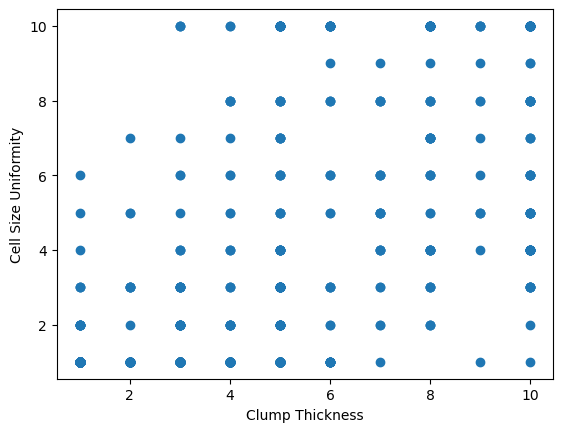

In [16]:
# Your code here ...

plt.scatter(df['clump_thickness'], df['cell_size_uniformity'])

plt.xlabel('Clump Thickness')
plt.ylabel('Cell Size Uniformity')

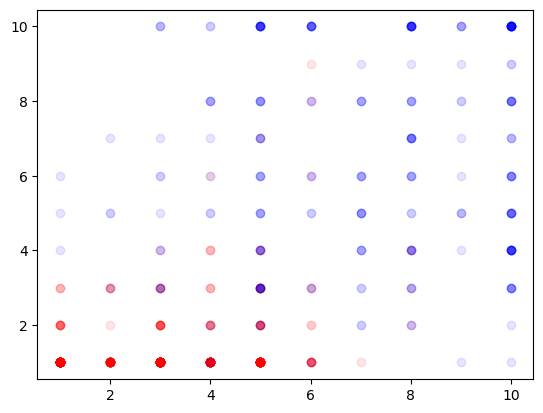

In [20]:
plt.scatter(df['clump_thickness'][df['class']==2], df['cell_size_uniformity'][df['class']==2], c='r', alpha=0.1)
plt.scatter(df['clump_thickness'][df['class']==4], df['cell_size_uniformity'][df['class']==4], c='b', alpha=0.1)